# Axe 1 : Conditions de travail

Dans ce notebook, j'étudie les variables liées aux facteurs organisationnelles des employés afin d'évaluer leur impact sur l'attrition.

Ce notebook a pour objectif :
- d'explorer les variables de l'axe,
- de comparer avec l'attrition
- d'explorer des relations internes à l’axe
- de visualiser
- retenir seulement ce qui ressort clairement
---

## 1. Exploration des variables de l’axe
---

### 1.1 Import des librairies & chargement des données
---

In [2]:
# import librairies 

import pandas as pd
import pyarrow
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [3]:
# chargement du df
df_clean = pd.read_parquet("C:/Users/Kemu/Documents/Formation/Projet Pro Data/2_Projets_Tests/projet-RH_test/data/processed/employees_clean.parquet")
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   string
 2   BusinessTravel            1470 non-null   string
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   string
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   string
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   string
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

### 1.2 Fonctions utilitaires

In [4]:
# Tableau de pourcentage variable univarié

def value_counts_percent(serie,round_n=3):

    """  Calcule la distribution (%) d'une variable catégorielle et retourne un DataFrame"""
    
    return (serie.value_counts(normalize=True).
            round(round_n).
            mul(100).
            reset_index(name="Pourcentage"))

# Tableau de pourcentage de variables bivariés
def groupby_percent(df,columns1,columns2,observed=True):
    """Calcule la distribution (%) de columns2 pour chaque modalité de columns1
    et retourne un DataFrame au format long. """
    return(df.groupby(columns1,observed=observed)[columns2].
           value_counts(normalize=True).
           round(2)
           *100).reset_index(name="Pourcentage")

# Table pivot en pourcentage de variables bivarié
def pivot_percent(df,index,columns):
    """ Crée un tableau pivot (%) : lignes=index, colonnes=columns."""
    df = groupby_percent(df,index,columns)
    return(df.pivot(index=index, columns=columns,values="Pourcentage").fillna(0))




### 1.3 Creation du DataFrame Condition de travail
---
#### Colonnes incluses dans l'axe "Condition de travail"

Cet axe regroupe les caractéristiques organisationnelles :
- BusinessTravel = Structure du poste = leger
- Department = Structure du poste = leger mais si gros impact interresant pour l'attrition
- JobLevel = Structure du poste = leger
- JobRole = Structure du poste = detaillé
- MonthlyIncome = Rémunération = detaillé
- OverTime = structure poste = detaillé
- PercentSalaryHike = Rémuneration = leger
- StockOptionLevel = Rémuneration = leger
- TotalWorkingYears = carriere = detaillé
- TrainingTimesLastYear = evolution = 
- YearsAtCompany = ancienneté = detaillé
- YearsInCurrentRole = carriere = detaillé
- YearsSinceLastPromotion = evolution = detaillé
- YearsWithCurrManager = manager = a voir en lien avec departement
 
Ces variables décrivent le contexte organisationnel susceptible d’influencer l’attrition.

In [5]:
# colonnes condition de travail
cols_conditions_travail = ['BusinessTravel', 'Department','JobLevel',"JobRole",'MonthlyIncome','OverTime','PercentSalaryHike','StockOptionLevel',
             "TotalWorkingYears", "TrainingTimesLastYear", "YearsAtCompany","YearsInCurrentRole","YearsSinceLastPromotion","YearsWithCurrManager" ]

# creation df_condition_Trav
df_conditions_travail = df_clean[cols_conditions_travail + ['Attrition']].copy()
df_conditions_travail.head(3)

,BusinessTravel,Department,JobLevel,JobRole,MonthlyIncome,OverTime,PercentSalaryHike,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Attrition
0,Travel_Rarely,Sales,2,Sales Executive,5993,Yes,11,0,8,0,6,4,0,5,Yes
1,Travel_Frequently,Research & Development,2,Research Scientist,5130,No,23,1,10,3,10,7,1,7,No
2,Travel_Rarely,Research & Development,1,Laboratory Technician,2090,Yes,15,0,7,3,0,0,0,0,Yes


#### 1.3.1 Préparation des variables
- Renommage pour la lisibilité
- Création de tranches
- Regroupements :Les seuils de regroupement peuvent différer selon les sous-thèmes afin de s’adapter à la distribution spécifique de chaque variable et à leur interprétation métier.


##### Renommage des niveaux hiérarchiques (JobLevel)

La variable *JobLevel*, codée de 1 à 5 dans le jeu de données, a été renommée en niveaux hiérarchiques allant de **niveau hiérarchique bas** à **niveau hiérarchique très senior**, afin d’en faciliter l’interprétation.  

Le niveau hiérarchique correspond au niveau du poste occupé et non à l’ancienneté ou à l’expérience totale, comme le montrent certaines observations où des employés de niveau hiérarchique bas présentent plusieurs années d’expérience.  

En l’absence de définition officielle fournie dans la documentation, ce renommage reste volontairement descriptif et neutre.


In [6]:

joblevel_name = {1 : "Niveau hiérarchique bas",
                2 : "Niveau hiérarchique intermédiaire",
                3 : "Niveau hiérarchique confirmé",
                4 : "Niveau hiérarchique senior",
                5 : "Niveau hiérarchique très senior"}

df_conditions_travail["JobLevel"] = df_conditions_travail["JobLevel"].replace(joblevel_name)
df_conditions_travail.JobLevel.head(2)

0    Niveau hiérarchique intermédiaire
1    Niveau hiérarchique intermédiaire
Name: JobLevel, dtype: object

##### Création des tranches des revenues mensuelle (MonthlyIncome)

Le revenu mensuel est une variable continue dont la distribution est fortement étalée.  
Afin de faciliter l’analyse et de rendre les résultats plus lisibles d’un point de vue RH, les revenus ont été regroupés en tranches interprétables, basées sur la médiane et sur des seuils cohérents en termes de niveaux de rémunération.

Ces tranches ne visent pas à répartir les effectifs de manière strictement équilibrée, mais à distinguer des profils de rémunération comparables :

- **Faible niveau de rémunération** : < 2 500  
- **Niveau de rémunération intermédiaire bas** : 2 500 – 5 000  
- **Niveau de rémunération intermédiaire haut** : 5 000 – 7 500  
- **Niveau de rémunération élevé** : > 7 500  

Ces tranches permettront d’analyser plus clairement la relation entre le revenu mensuel et l’attrition.

In [7]:
df_conditions_travail["Tranche_Salaire"]= pd.cut(
        df_conditions_travail["MonthlyIncome"],
        bins=[0, 2500, 5000, 7500, 20000],
        labels=["< 2 500", "2 500 - 5 000", "5 000 - 7 500" , "> 7 500"],
        ordered=True,
        include_lowest=True)
df_conditions_travail.Tranche_Salaire.head(2)

0    5 000 - 7 500
1    5 000 - 7 500
Name: Tranche_Salaire, dtype: category
Categories (4, object): ['< 2 500' < '2 500 - 5 000' < '5 000 - 7 500' < '> 7 500']

##### Création des tranches du pourcentage d’augmentation de salaire (PercentSalaryHike)

Pour faciliter l’analyse exploratoire et rendre les visualisations plus lisibles, le pourcentage d’augmentation de salaire a été regroupé en tranches cohérentes :

- **Faible niveau d’augmentation de salaire** : < 12  
- **Niveau d’augmentation de salaire intermédiaire** : 12 – 15  
- **Niveau d’augmentation de salaire intermédiaire haut** : 15 – 18  
- **Niveau d’augmentation de salaire élevé** : > 18  

Ces catégories permettent d’identifier plus facilement d’éventuelles relations entre le pourcentage d’augmentation de salaire et l’attrition.


In [8]:
df_conditions_travail["Tranche_PercentSalaryHike"]= pd.cut(
        df_conditions_travail["PercentSalaryHike"],
        bins=[0, 12, 15, 18, 30],
        labels=["< 12", "12-15", "15-18", "> 18"],
        ordered=True,
        include_lowest=True)

df_conditions_travail.Tranche_PercentSalaryHike.head(2)

0    < 12
1    > 18
Name: Tranche_PercentSalaryHike, dtype: category
Categories (4, object): ['< 12' < '12-15' < '15-18' < '> 18']

##### Renommage des niveaux de stock-options (StockOptionLevel)

La variable *StockOptionLevel*, codée de 0 à 3 dans le jeu de données, a été renommée afin d’en améliorer la lisibilité.  
Les niveaux de stock-options sont traités comme une variable catégorielle ordonnée, sans hypothèse sur leur valeur monétaire.

In [9]:
stockOptionLevel_name = {
    0 : "Aucun",
    1 : "Niveau 1",
    2 : "Niveau 2",
    3 : "Niveau 3"
}
df_conditions_travail["StockOptionLevel"] = df_conditions_travail["StockOptionLevel"].replace(stockOptionLevel_name)
df_conditions_travail.StockOptionLevel.head(3)


0       Aucun
1    Niveau 1
2       Aucun
Name: StockOptionLevel, dtype: object

##### Création des tranches pour l'ancienneté dans l'entreprise  (YearsAtCompany) 

L’ancienneté dans l’entreprise est une variable continue dont la distribution est relativement étalée. Afin de faciliter l’analyse et d’améliorer la lisibilité des résultats d’un point de vue RH, cette variable a été regroupée en tranches interprétables, basées sur des seuils cohérents avec les étapes classiques d’un parcours professionnel.

- **Nouveaux salariés** : ≤ 2 ans
- **Ancienneté courte** : 3 – 5 ans
- **Ancienneté intermédiaire** : 6 – 10 ans
- **Ancienneté longue**: 11 – 15 ans
- **Ancienneté très longue** : 16 – 20 ans
- **Ancienneté exceptionnelle** : > 20 ans

Ces catégories permettent de distinguer les phases d’intégration, de stabilisation et de fidélisation des salariés, et facilitent l’identification d’éventuelles relations entre l’ancienneté dans l’entreprise et l’attrition.


In [10]:
df_conditions_travail["Tranche_Anciennete"] = pd.cut(
        df_conditions_travail["YearsAtCompany"],
        bins=[0, 2, 5, 10, 15, 20, 100],
        labels=["≤ 2 ans", "3-5 ans", "6-10 ans", "11-15 ans", "16-20 ans", "> 20 ans"],
        ordered=True,
        include_lowest=True)

df_conditions_travail.Tranche_Anciennete.head(2)

0    6-10 ans
1    6-10 ans
Name: Tranche_Anciennete, dtype: category
Categories (6, object): ['≤ 2 ans' < '3-5 ans' < '6-10 ans' < '11-15 ans' < '16-20 ans' < '> 20 ans']

##### Création des tranches pour l'ancienneté dans le poste actuel de l'employé  (YearsInCurrentRole) 

L’ancienneté dans le poste actuel est une variable continue dont la distribution est relativement étalée. Afin de faciliter l’analyse exploratoire et d’améliorer la lisibilité des visualisations, cette variable a été regroupée en tranches cohérentes correspondant aux différentes phases d’occupation d’un poste.

- **Prise de poste récente**: ≤ 2 ans
- **Poste stabilisé** : 3 – 5 ans
- **Poste confirmé** : 6 – 10 ans
- **Poste très expérimenté**: > 10 ans

Ces catégories permettent d’identifier plus facilement d’éventuelles relations entre l'ancienneté dans le poste et l’attrition.

In [11]:
df_conditions_travail["Tranche_PosteAnciennete"] = pd.cut(
        df_conditions_travail.YearsInCurrentRole,
        bins=[0, 2, 5, 10, 100],
        labels=["≤ 2 ans", "3-5 ans", "6-10 ans", "> 10 ans"],
        ordered=True,
        include_lowest=True)

df_conditions_travail.Tranche_PosteAnciennete.head(2)

0     3-5 ans
1    6-10 ans
Name: Tranche_PosteAnciennete, dtype: category
Categories (4, object): ['≤ 2 ans' < '3-5 ans' < '6-10 ans' < '> 10 ans']

##### Création des tranches pour le nombre total d'expérience professionnelle de l'employé  (TotalWorkingYears) 

L’expérience professionnelle totale du salarié est une variable continue dont la distribution est relativement étalée. Afin de faciliter l’analyse exploratoire et d’améliorer la lisibilité des visualisations, cette variable a été regroupée en tranches cohérentes correspondant aux grandes étapes d’un parcours professionnel.

- **Expérience professionnelle très récente** : ≤ 2 ans
- **Expérience professionnelle courte**: 3 – 5 ans
- **Expérience professionnelle intermédiaire** : 6 – 10 ans
- **Expérience professionnelle longue** : 11 – 15 ans
- **Expérience professionnelle très longue** : > 15 ans


Les catégories permettent de mieux décrire la répartition des employés selon leur expérience professionnelle globale et de faciliter l’identification d’éventuelles relations avec l’attrition.

In [12]:
df_conditions_travail["Tranche_ExperiencePro"] = pd.cut(
        df_conditions_travail.TotalWorkingYears,
        bins=[0, 2, 5, 10, 15, 100],
        labels=["≤ 2 ans", "3-5 ans", "6-10 ans", "11-15 ans", "> 15 ans"],
        ordered=True,
        include_lowest=True)

df_conditions_travail.Tranche_ExperiencePro.head(2)

0    6-10 ans
1    6-10 ans
Name: Tranche_ExperiencePro, dtype: category
Categories (5, object): ['≤ 2 ans' < '3-5 ans' < '6-10 ans' < '11-15 ans' < '> 15 ans']


##### Création des tranches pour le nombre d’années écoulées depuis la dernière promotion (YearsSinceLastPromotion)

La variable *YearsSinceLastPromotion* est une variable continue dont la distribution est relativement étalée. Afin de faciliter l’analyse exploratoire et d’améliorer la lisibilité des visualisations, cette variable a été regroupée en tranches cohérentes correspondant aux grandes étapes d’un parcours professionnel.

- **Promotion très récente** : < 1 an
- **Promotion récente**: 1–2 ans
- **Promotion intermédiaire** : 3–5 ans
- **Promotion longue** : 6-10  ans
- **Promotion très longue** : > 10 ans


Ces catégories permettent de mieux décrire la répartition des employés selon le délai écoulé depuis leur dernière promotion et de faciliter l’identification d’éventuelles relations avec l’attrition.



In [13]:
df_conditions_travail["Tranche_LastPromotion"] = pd.cut(
        df_conditions_travail.YearsSinceLastPromotion,
        bins=[0, 1, 2, 5, 10, 100 ],
        labels=["< 1 an", "1-2 ans", "3-5 ans", "6-10 ans", "> 10 ans"],
        ordered=True,
        include_lowest=True)

df_conditions_travail.Tranche_LastPromotion.head(2)

0    < 1 an
1    < 1 an
Name: Tranche_LastPromotion, dtype: category
Categories (5, object): ['< 1 an' < '1-2 ans' < '3-5 ans' < '6-10 ans' < '> 10 ans']

##### Création des tranches pour la durée de collaboration avec le manager actuel (YearsWithCurrManager)

La variable *YearsWithCurrManager* est une variable continue dont la distribution est relativement étalée. Afin de faciliter l’analyse exploratoire et d’améliorer la lisibilité des visualisations, cette variable a été regroupée en tranches cohérentes correspondant aux grandes étapes de la collaboration entre un employé et son manager actuel.

- **Collaboration très récente** : < 1 an
- **Collaboration récente** : 1 – 2 ans
- **Collaboration intermédiaire** : 3 – 5 ans
- **Collaboration longue** : 6 – 10 ans
- **Collaboration très longue** : > 10 ans

Ces catégories permettent de mieux décrire la répartition des employés selon la durée de collaboration avec leur manager actuel et de faciliter l’identification d’éventuelles relations avec l’attrition.



In [14]:
df_conditions_travail["Tranche_CurManager"] = pd.cut(
        df_conditions_travail.YearsWithCurrManager,
        bins=[0, 1, 2, 5, 10, 100],
        labels=["< 1 ans", "1-2 ans", "3-5 ans ", "6-10 ans", "> 10 ans"],
        ordered=True,
        include_lowest=True) 

df_conditions_travail.Tranche_CurManager.head()

0    3-5 ans 
1    6-10 ans
2     < 1 ans
3     < 1 ans
4     1-2 ans
Name: Tranche_CurManager, dtype: category
Categories (5, object): ['< 1 ans' < '1-2 ans' < '3-5 ans ' < '6-10 ans' < '> 10 ans']

### 1.4  Analyse individuelle des variables 
---
Dans cette section, l’analyse porte sur plusieurs caractéristiques des conditions de travail des employés, afin de mieux comprendre le contexte organisationnel de la population étudiée.

Les variables sont analysées selon différents sous-thèmes :
- la structure du poste,
- la rémunération,
- l’ancienneté et la carrière,
- le management et l’évolution professionnelle.

Certaines variables seront analysées de manière plus approfondie que d’autres.
Cette analyse repose sur une approche **descriptive**, basée sur l’étude des **distributions**, à l’aide de **tableaux de proportions** et de **visualisations graphiques**.

#### 1.4.1 Structure du poste
---
Cette section est consacrée à l’exploration des variables liées à la **structure du poste**, qui regroupent les caractéristiques organisationnelles du travail et certaines conditions professionnelles des employés.

Les variables étudiées sont les suivantes :

- **Department** : correspond au département de rattachement de l’employé au sein de l’entreprise.
- **JobRole** : désigne le poste occupé par l’employé.
- **JobLevel** : indique le niveau hiérarchique ou le niveau de poste de l’employé.
- **BusinessTravel** : représente la fréquence des déplacements professionnels effectués par l’employé.
- **OverTime** : précise si l’employé effectue ou non des heures supplémentaires.

Dans le cadre de cette analyse :
- **BusinessTravel**, **Department** et **JobLevel** feront l’objet d’une analyse descriptive légère.
- **JobRole** et **OverTime** seront analysées de manière plus détaillée.


Les variables de ce sous-thème sont décrites à travers leurs répartitions afin de mieux comprendre la structure des postes au sein de l’entreprise.

##### 1.4.1.1 Departement de rattachement de l'employé (department)

##### Tableau des proportions

In [15]:
department_count = value_counts_percent(df_conditions_travail["Department"])
department_count

,Department,Pourcentage
0,Research & Development,65.4
1,Sales,30.3
2,Human Resources,4.3


Les employés sont répartis en trois départements.  
Le département majoritaire est **Research & Development**, suivi du département **Sales**, tandis que le département **Human Resources** est minoritaire.

##### 1.4.1.2 Le poste occupé par l'employé (jobRole)

##### Tableau des proportions

In [16]:
jobRole_count = value_counts_percent(df_conditions_travail["JobRole"])
jobRole_count

,JobRole,Pourcentage
0,Sales Executive,22.2
1,Research Scientist,19.9
2,Laboratory Technician,17.6
3,Manufacturing Director,9.9
4,Healthcare Representative,8.9
5,Manager,6.9
6,Sales Representative,5.6
7,Research Director,5.4
8,Human Resources,3.5


###### Répartitions des employés selon leur fonction

Ce graphique montre que trois fonctions sont particulièrement représentées :
- **Sales Executive** (≈22 %)
- **Research Scientist** (≈20 %)
- **Laboratory Technician** (≈18 %)

Les fonctions minoritaires sont **Human Resources** (≈4 %) et **Research Director** / **Sales Representative** (≈5–6 %).

Cette exploration permet d’avoir une première vision des fonctions présentes dans l’entreprise et d’apprécier la diversité des profils métiers.

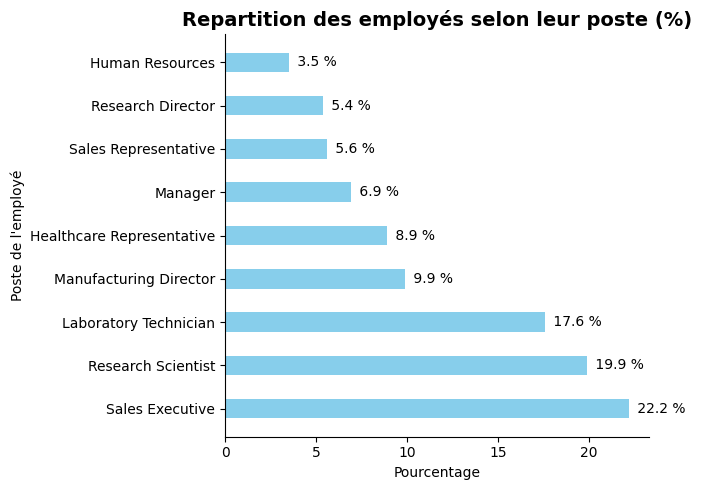

(None,)

In [17]:
fig , ax = plt.subplots(figsize=(7,5))

ax.spines['top'].set_visible(False)
ax.spines["right"].set_visible(False)

# Données
x = np.arange(len(jobRole_count["JobRole"]))
y = jobRole_count["Pourcentage"]

# Barplot
barhs = ax.barh(x, y, height=0.45, color="skyblue")
# Pourcentage affiché
ax.bar_label(barhs, labels=[f'{v : .1F} %' for v in y ], padding=3)

# axes et labels
ax.set_yticks(x)
ax.set_yticklabels(jobRole_count["JobRole"])
ax.set_xlabel("Pourcentage")
ax.set_ylabel("Poste de l'employé")
ax.set_title("Repartition des employés selon leur poste (%)", fontsize=14, fontweight="bold")
fig.tight_layout()
plt.show(),


##### 1.4.1.3 Le niveau hiérachiques (Joblevel)

##### Tableau des proportions

In [18]:
jobLevel_count = value_counts_percent(df_conditions_travail["JobLevel"])
jobLevel_count

,JobLevel,Pourcentage
0,Niveau hiérarchique bas,36.9
1,Niveau hiérarchique intermédiaire,36.3
2,Niveau hiérarchique confirmé,14.8
3,Niveau hiérarchique senior,7.2
4,Niveau hiérarchique très senior,4.7


On observe que la majorité des employés occupent un **niveau hiérarchique bas** ou **intermédiaire** (≈70 %).  
À l’inverse, les employés ayant un **niveau hiérarchique très senior** représentent environ **5 %** de l’effectif.

##### 1.4.1.5 Les déplacements professionelles (BusinessTravel)

##### Tableau des proportions

In [19]:
businesstravel_count = value_counts_percent(df_conditions_travail["BusinessTravel"])
businesstravel_count

,BusinessTravel,Pourcentage
0,Travel_Rarely,71.0
1,Travel_Frequently,18.8
2,Non-Travel,10.2


On observe qu’une large majorité des employés déclarent **voyager rarement pour des raisons professionnelles** (≈71 %).  
À l’inverse, environ **10 %** des salariés déclarent ne **jamais effectuer de déplacements professionnels**.

##### 1.4.1.5 Les heures Supplémentaires (Overtime)

##### Tableau des proportions

In [20]:
overtime_count = value_counts_percent(df_conditions_travail["OverTime"])
overtime_count

,OverTime,Pourcentage
0,No,71.7
1,Yes,28.3


###### Répartitions des employés en fonctions des heures supplémentaires.

On observe qu’une majorité des employés (**environ 72 %**) déclarent effectuer des heures supplémentaires au sein de l’entreprise.

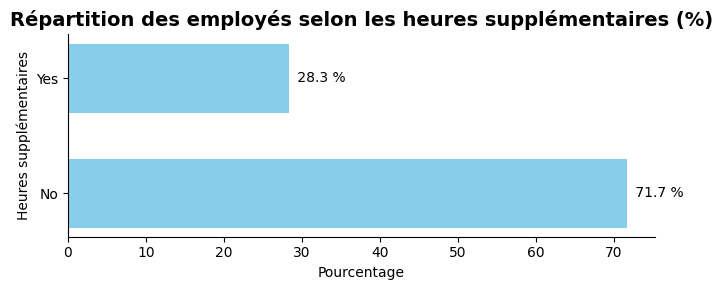

(None,)

In [21]:
fig, ax = plt.subplots(figsize=(7,3))

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# données
x= np.arange(len(overtime_count.index))
y = overtime_count["Pourcentage"]

# barplot
barhs = ax.barh(x, y, height=0.6, color="skyblue")

# Pourcentage affiché
ax.bar_label(barhs, labels=[f'{v : .1F} %' for v in y], padding=3)

# axes et labels
ax.set_yticks(x)
ax.set_yticklabels(overtime_count["OverTime"])


ax.set_xlabel("Pourcentage")
ax.set_ylabel("Heures supplémentaires")
ax.set_title("Répartition des employés selon les heures supplémentaires (%)", fontsize=14, fontweight="bold")
fig.tight_layout()
plt.show(),

**Mini-synthèse - Structure du poste**

L’analyse de la structure des postes offre une première vision du contexte organisationnel de l’entreprise.
Les employés sont majoritairement répartis entre les départements **Research & Development** et **Sales**, ce qui est cohérent avec les postes les plus représentés, tels que **Sales Executive**, **Research Scientist** et **Laboratory Technician**.

La majorité des employés (environ **70 %**) occupent des niveaux hiérarchiques **bas ou intermédiaires** et déclarent **voyager rarement** pour des raisons professionnelles.

Par ailleurs, près de **trois quarts des employé**s déclarent effectuer **des heures supplémentaires**, ce qui caractérise une organisation du travail dans laquelle cette pratique est largement répandue.

Après avoir décrit la structure des postes au sein de l’entreprise, l’analyse se poursuit avec les variables liées à la rémunération, afin de caractériser les niveaux de revenus et les éléments financiers associés aux conditions de travail.

#### 1.4.2 Rémunération
---
Cette section s’intéresse aux variables liées à la **rémunération et aux éléments financiers associés**.

Les variables analysées sont :

- **MonthlyIncome** : correspond au revenu mensuel de l’employé.
- **PercentSalaryHike** : indique le pourcentage d’augmentation de salaire.
- **StockOptionLevel** : représente le niveau d’options d’actions attribuées à l’employé.

Dans le cadre de cette analyse :
- **StockOptionLevel** fera l’objet d’une analyse descriptive légère.
- **MonthlyIncome*** et **PercentSalaryHike** seront analysées de manière plus détaillée.

 
Ces variables sont analysées de manière descriptive afin de caractériser la distribution des niveaux de rémunération au sein de l’entreprise.

##### 1.4.2.1 Le revenu mensuel de l'employé (MonthlyIncome)

##### Tableau des proportions

In [22]:
MonthlyIncome_count = value_counts_percent(df_conditions_travail["Tranche_Salaire"])
MonthlyIncome_count 


,Tranche_Salaire,Pourcentage
0,2 500 - 5 000,35.6
1,> 7 500,28.0
2,5 000 - 7 500,21.1
3,< 2 500,15.4


##### Répartitions des employés en fonctions de leur revenu mensuel.

Ce graphique montre que deux tranches de revenu sont particulièrement représentées :
- la tranche **2 500 – 5 000** (≈36 %),
- la tranche **> 7 500** (≈28 %).

Les tranches plus minoritaires sont **5 000 – 7 500** (≈21 %) et **< 2 500** (≈15 %).

Cette exploration met en évidence les grandes lignes de l’échelle salariale et permet d’apprécier la diversité des profils de rémunération au sein de l’entreprise.


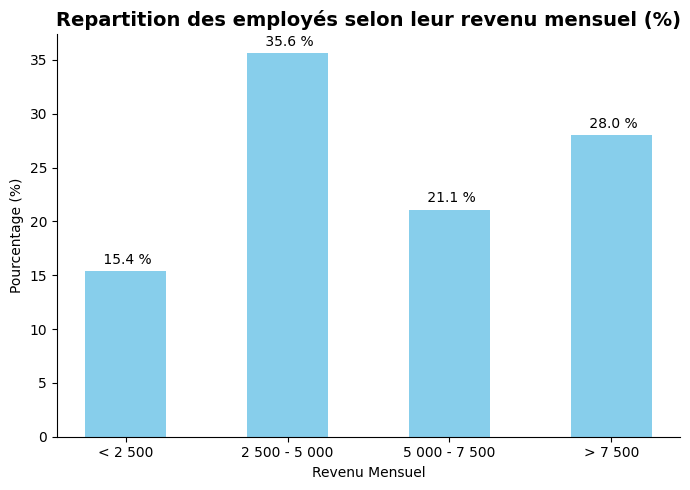

(None,)

In [23]:
MonthlyIncome_count = MonthlyIncome_count.sort_values("Tranche_Salaire", ascending=True)

fig, ax = plt.subplots(figsize=(7,5))

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Données
x = np.arange(len(MonthlyIncome_count.index))
y = MonthlyIncome_count["Pourcentage"]

# Barplot
barhs = ax.bar(x, y, width=0.5, color="skyblue")

# Pourcentage
ax.bar_label(barhs, labels=[f"{v : .1F} %" for v in y], padding=3)

# Axes et labels
ax.set_xticks(x)
ax.set_xticklabels(MonthlyIncome_count["Tranche_Salaire"])
ax.set_xlabel("Revenu Mensuel")
ax.set_ylabel("Pourcentage (%)")
ax.set_title("Repartition des employés selon leur revenu mensuel (%)", fontsize=14, fontweight="bold")
fig.tight_layout()
plt.show(),

##### 1.4.2.2 Le pourcentage d’augmentation de salaire de l'employé (PercentSalaryHike)

##### Tableau des proportions

In [24]:
PercentSalaryHike_count = value_counts_percent(df_conditions_travail["Tranche_PercentSalaryHike"])
PercentSalaryHike_count

,Tranche_PercentSalaryHike,Pourcentage
0,12-15,34.8
1,< 12,27.8
2,> 18,20.5
3,15-18,16.9


##### Répartition des employés selon leur pourcentage d’augmentation de salaire

Ce graphique montre que deux tranches sont particulièrement représentées :
- la tranche **12–15 %** d’augmentation de salaire (≈35 %),
- la tranche **< 12 %** (≈28 %).

Les tranches plus minoritaires sont **> 18 %** (≈21 %) et **15–18 %** (≈17 %).

Cette exploration permet d’avoir une première vision des niveaux d’augmentation de salaire au sein de l’entreprise.


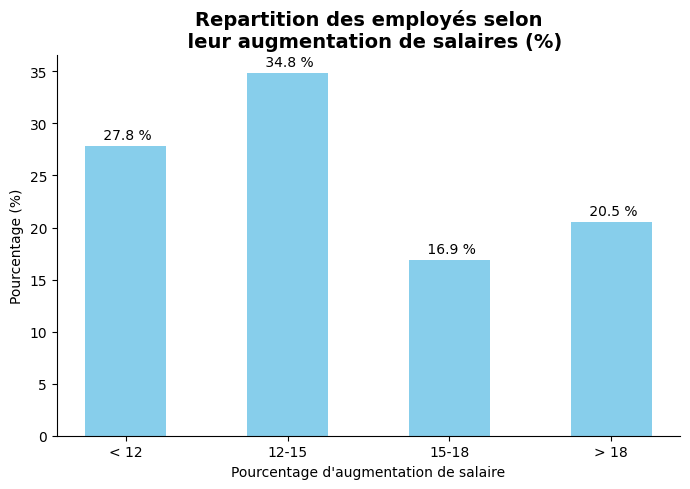

(None,)

In [55]:
PercentSalaryHike_count = PercentSalaryHike_count.sort_values("Tranche_PercentSalaryHike", ascending=True)

fig, ax = plt.subplots(figsize=(7,5))


ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Données
x = np.arange(len(PercentSalaryHike_count.index))
y = PercentSalaryHike_count["Pourcentage"]

# Barplot
barhs = ax.bar(x, y, width=0.5, color="skyblue")

# Pourcentage
ax.bar_label(barhs, labels=[f"{v : .1F} %" for v in y], padding=3)

# Axes et labels
ax.set_xticks(x)
ax.set_xticklabels(PercentSalaryHike_count["Tranche_PercentSalaryHike"])
ax.set_xlabel("Pourcentage d'augmentation de salaire")
ax.set_ylabel("Pourcentage (%)")
ax.set_title("Repartition des employés selon\n  leur augmentation de salaires (%)", fontsize=14, fontweight="bold")
fig.tight_layout()
plt.show(),

##### 1.4.2.3 Le niveau de stock-option attribué à l'employé (StockOptionLevel)

##### Tableau des proportions

In [26]:
stockOptionLevel_count = value_counts_percent(df_conditions_travail["StockOptionLevel"])
stockOptionLevel_count

,StockOptionLevel,Pourcentage
0,Aucun,42.9
1,Niveau 1,40.5
2,Niveau 2,10.7
3,Niveau 3,5.8


On observe que la majorité des employés ne bénéficient **d’aucune stock-option** ou disposent d’un **niveau 1 de stock-options** (≈83 %).  

À l’inverse, les employés ayant un **niveau 3 de stock-options** représentent environ **6 %** de l’effectif.

Cette exploration met en évidence les grandes lignes d’un élément de rémunération variable attribué à une partie limitée des salariés.

**Mini-synthèse - Rémuneration**

L’analyse de la rémunération met en évidence une distribution **hétérogène**des revenus mensuels au sein de l’entreprise.
Une part importante des employés se situe dans des tranches de rémunération **intermédiaires**, tandis qu’une proportion non négligeable appartient aux tranches **de revenus élevés**.

Les augmentations de salaire sont principalement concentrées sur **des niveaux faibles à intermédiaire**, les hausses les plus élevées restant minoritaires.

Enfin, la majorité des employés ne bénéficie **d’aucune ou de faibles stock-options** , ces dispositifs concernant une population restreinte.


#### 1.4.3 Ancienneté et carrière
---
Cette section porte sur les variables décrivant l’**ancienneté** et le **parcours professionnel** des employés.

Les variables étudiées sont :

- **YearsAtCompany** : représente le nombre d’années passées par l’employé dans l’entreprise.
- **YearsInCurrentRole** : correspond à l’ancienneté dans le poste actuel.
- **TotalWorkingYears** : indique le nombre total d’années d’expérience professionnelle.

Dans le cadre de cette analyse :
- **YearsInCurrentRole** fera l’objet d’une analyse descriptive légère.
- **YearsAtCompany*** et **TotalWorkingYearse** seront analysées de manière plus détaillée.


L’analyse de ces variables permet de décrire le niveau d’expérience et l’ancienneté des employés au sein de l’organisation.


##### 1.4.3.1 L'ancienneté dans l'entreprise (YearsAtCompany)

##### Tableau des proportions

In [27]:
YearsAtCompany_count = value_counts_percent(df_conditions_travail["Tranche_Anciennete"])
YearsAtCompany_count


,Tranche_Anciennete,Pourcentage
0,6-10 ans,30.5
1,3-5 ans,29.5
2,≤ 2 ans,23.3
3,11-15 ans,7.3
4,16-20 ans,4.9
5,> 20 ans,4.5


##### Répartitions des employés en fonctions de leur ancienneté.
Ce graphique montre que deux tranches d'ancienneté sont particulièrement représentées :
- la tranche **6-10 ans** (≈31 %),
- la tranche **3-5 ans** (≈30 %).

Les tranches plus minoritaires sont **> 20 ans** et **16-20 ans** (≈5 %). A noter que la tranche **des nouveaux salariés (< 2 ans)** représentent environ 23 %.

Cette exploration permet d’avoir une première vision de la dynamique interne de l’entreprise.

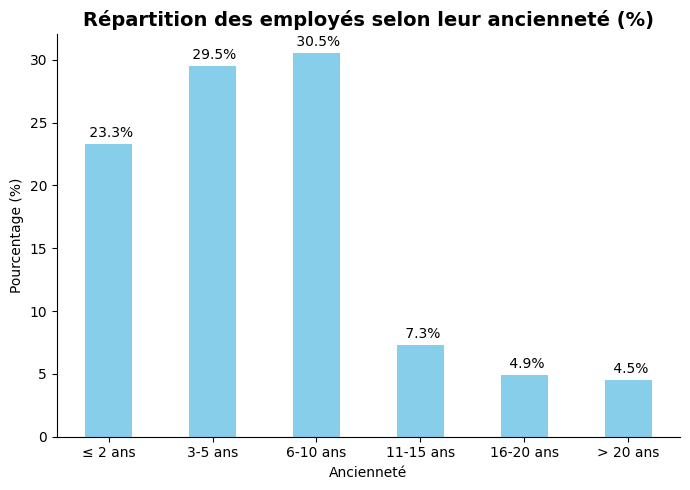

In [28]:
YearsAtCompany_count = YearsAtCompany_count.sort_values("Tranche_Anciennete", ascending=True)

fig, ax = plt.subplots(figsize=(7,5))

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Données
x = np.arange(len(YearsAtCompany_count.index))
y = YearsAtCompany_count.Pourcentage

# Barplot
bars = ax.bar(x, y, width=0.45, color="skyblue")

# Pourcentage affiché

ax.bar_label(bars, labels=[f"{v : .1F}%" for v in y], padding=3)

# Axes et labels
ax.set_xticks(x)
ax.set_xticklabels(YearsAtCompany_count.Tranche_Anciennete)
ax.set_xlabel("Ancienneté")
ax.set_ylabel("Pourcentage (%)")
ax.set_title("Répartition des employés selon leur ancienneté (%)", fontsize=14, fontweight="bold")
fig.tight_layout()
plt.show()

##### 1.4.3.2 L'ancienneté dans le poste actuel des salariés (YearsInCurrentRole)

##### Tableau des proportions

In [29]:
YearsInCurrentRole_count = value_counts_percent(df_conditions_travail.Tranche_PosteAnciennete)
YearsInCurrentRole_count

,Tranche_PosteAnciennete,Pourcentage
0,≤ 2 ans,45.8
1,6-10 ans,30.2
2,3-5 ans,18.7
3,> 10 ans,5.3


On observe que deux tranches d'ancienneté dans le poste sont particulièrement représentées à elles deux, ces tranches représentent environ **76 %** des effectifs
- la tranche **≤ 2 ans** (≈46 %),
- la tranche **6-10 ans** (≈30 %).

Les tranches plus minoritaires sont **> 10 ans** (≈5 %) et la tranche **3-5 ans** (≈19 %). 

Cette exploration permet de dégager les grandes tendances relatives à la durée d’occupation du poste actuel par les employés de l’entreprise.

##### 1.4.3.3 le nombre total d’années d’expérience professionnelle (TotalWorkingYears)

##### Tableau des proportions

In [30]:
TotalWorkingYear_count = value_counts_percent(df_conditions_travail.Tranche_ExperiencePro)
TotalWorkingYear_count

,Tranche_ExperiencePro,Pourcentage
0,6-10 ans,41.3
1,> 15 ans,24.2
2,3-5 ans,13.1
3,11-15 ans,13.0
4,≤ 2 ans,8.4


##### Répartitions des employés en fonctions de leur expériences professionnelle totale.

Ce graphique met en évidence une tranche d’expérience professionnelle particulièrement représentée : **la tranche 6–10 ans**, qui regroupe environ **41 %** des employés. Elle est suivie par **la tranche supérieure à 15 ans**, représentant **environ 24 %** de l’effectif.

À l’inverse, **la tranche ≤ 2 ans** apparaît comme la moins représentée, avec **environ 8 %** des employés.

Cette exploration descriptive permet d’obtenir une première vision de la répartition de l’expérience professionnelle au sein de l’entreprise.

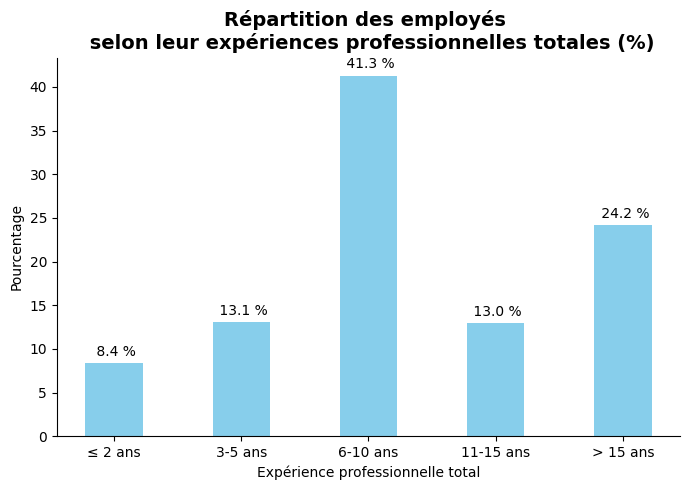

(None,)

In [54]:
TotalWorkingYear_count = TotalWorkingYear_count.sort_values("Tranche_ExperiencePro", ascending=True)

fig, ax = plt.subplots(figsize=(7,5))

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Données 
x = np.arange(len(TotalWorkingYear_count.index))
y = TotalWorkingYear_count.Pourcentage

# Barplot
bars = ax.bar(x, y, width=0.45, color="skyblue")

# Pourcentage affiché
ax.bar_label(bars, labels=[f"{v : .1F} %" for v in y], padding=3)

# Axes et labels
ax.set_xticks(x)
ax.set_xticklabels(TotalWorkingYear_count.Tranche_ExperiencePro)

ax.set_xlabel("Expérience professionnelle total")
ax.set_ylabel("Pourcentage")
ax.set_title("Répartition des employés \n selon leur expériences professionnelles totales (%)", fontsize=14, fontweight="bold")
fig.tight_layout()
plt.show(),

**Mini-synthèse - Ancienneté et carrière**

L’analyse de l’ancienneté et du parcours professionnel met en évidence une population composée majoritairement d’employés ayant une ancienneté comprise **entre 0 et 10 ans** au sein de l’entreprise.
Les employés avec une ancienneté supérieure à 10 ans sont nettement moins représentés.

L’ancienneté dans le poste actuel est majoritairement **récente ou intermédiaire**, tandis que les postes occupés depuis plus de 10 ans restent minoritaires.

En termes d’expérience professionnelle totale, les employés présentent majoritairement des niveaux **intermédiaires à élevés**, alors que les profils très peu expérimentés sont peu représentés.

#### 1.4.4 Management et évolution
---

Cette dernière section explore les variables relatives au **management** et aux **aspects de l’évolution professionnelle**

Les variables analysées sont :

- **YearsSinceLastPromotion** : indique le nombre d’années écoulées depuis la dernière promotion de l’employé.
- **TrainingTimesLastYear** : correspond au nombre de formations suivies au cours de l’année précédente.
- **YearsWithCurrManager** : représente la durée de collaboration avec le manager actuel.

Dans le cadre de cette analyse :
- **TrainingTimesLastYear** et **YearsWithCurrManager** feront l’objet d’une analyse descriptive légère.
- **YearsSinceLastPromotion** sera analysée de manière plus détaillée.

Ces variables sont décrites afin de mieux caractériser le contexte managérial et les parcours d’évolution au sein de l’entreprise.

##### 1.4.4.1 le nombre d’années écoulées depuis la derniere promotion (YearsSinceLastPromotion)

##### Tableau des proportions

In [32]:
yearsSinceLastPromotion_count = value_counts_percent(df_conditions_travail.Tranche_LastPromotion)
yearsSinceLastPromotion_count

,Tranche_LastPromotion,Pourcentage
0,< 1 an,63.8
1,1-2 ans,10.8
2,3-5 ans,10.7
3,6-10 ans,10.1
4,> 10 ans,4.5


##### Répartitions des employés en fonctions du délai écoulé depuis la derniere promotion.

Ce graphique met en évidence une tranche de délai particulièrement représentée : **moins d' 1 ans**, qui regroupe environ **64 %** des employés.

Les tranches **1-2 ans**, **3-5 ans** et **6-10 ans** représentent chacune une part comprise *entre 10 et 11 %* des employés.

A l'inverse, la tranche  **supérieure à 10 ans** apparait comme la moins représentée avec environs 5 % des employés.

Cette exploration descriptive permet d’obtenir une première vision de la répartition du delai écoulé depuis la derniere promotion au sein de l’entreprise.

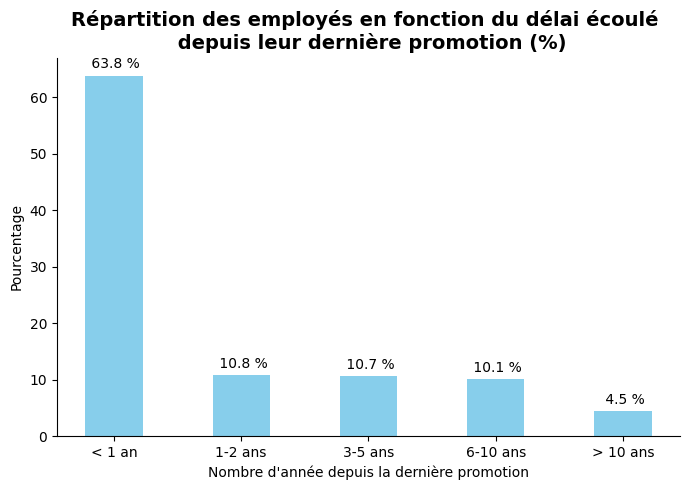

(None,)

In [33]:
yearsSinceLastPromotion_count = yearsSinceLastPromotion_count.sort_values("Tranche_LastPromotion", ascending=True)

fig , ax = plt.subplots(figsize=(7,5))

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Données
x = np.arange(len(yearsSinceLastPromotion_count.index))
y = yearsSinceLastPromotion_count.Pourcentage

# Barplot
bars = ax.bar(x, y, width=0.45, color="skyblue")

# Pourcentage affiché
ax.bar_label(bars, labels=[f"{v : .1F} %" for v in y], padding=3)

# Axes et labels
ax.set_xticks(x)
ax.set_xticklabels(yearsSinceLastPromotion_count.Tranche_LastPromotion)
ax.set_xlabel("Nombre d'année depuis la dernière promotion")
ax.set_ylabel("Pourcentage")
ax.set_title("Répartition des employés en fonction du délai écoulé \n depuis leur dernière promotion (%)", fontsize=14, fontweight="bold")
fig.tight_layout()
plt.show(),

##### 1.4.4.2 le nombre de formations suivies au cours de l'année précédente (TrainingTimesLastYear)

##### Tableau des proportions

In [34]:
trainingTimesLastYear_count = value_counts_percent(df_conditions_travail.TrainingTimesLastYear)
trainingTimesLastYear_count

,TrainingTimesLastYear,Pourcentage
0,2,37.2
1,3,33.4
2,4,8.4
3,5,8.1
4,1,4.8
5,6,4.4
6,0,3.7


On observe qu'une large majorité des employés ont suivi  **entre 2 et 3 formrationS** au cours de l'année écoulée représentant environ 71 % de l'effectif.
les employés ayant suivi **entre 4 et 5 formations** representent environs 16 % de l'effectifs.

A l'inverse, une minorité d'employés n'a suivi aucune formation sur la periodes considérée soit environs 4 %.

##### 1.4.4.3 la durée de collaboration avec le manager actuel (YearsWithCurrManage)


##### Tableau des proportions

In [35]:
yearsWithCurrManager_count = value_counts_percent(df_conditions_travail.Tranche_CurManager)
yearsWithCurrManager_count

,Tranche_CurManager,Pourcentage
0,6-10 ans,30.1
1,1-2 ans,23.4
2,< 1 ans,23.1
3,3-5 ans,18.4
4,> 10 ans,5.0


L’analyse de la durée de collaboration avec le manager actuel montre que trois tranches sont particulièrement représentées :
- **6-10 ans** regroupant environ 30 % des employés
- **1-2 ans** et **moins d'un an** représentant chacune environ 23 % de l’effectif.

La tranche **supérieure à 10 ans** apparaît comme la moins représentée, avec environ 5 % des employés.

**Mini-synthèse - Management et évolution**

L’analyse des variables liées au management et à l’évolution professionnelle montre qu’une majorité d’employés a bénéficié **d’une promotion récente**, avec un délai inférieur à un an pour une part importante de l’effectif.

Les actions de formation sont fortement concentrées, la majorité des employés (environ 71 %) ayant suivi 2 à 3 formations au cours de l’année écoulée, tandis que les profils très peu ou très fortement formés restent minoritaires.

Enfin , la durée de collaboration avec le manager actuel se répartit entre différentes tranches d’ancienneté, la tranche de 6 à 10 ans étant la plus représentée, tandis que les collaborations de plus de 10 ans demeurent limitées.

Après avoir décrit les principales caractéristiques des conditions de travail des employés, cette section s’intéresse désormais à leur relation avec l’attrition.

L’objectif est d’observer si certaines dimensions organisationnelles — telles que le poste occupé, la rémunération, l’ancienneté ou les opportunités d’évolution — présentent des différences de taux d’attrition selon les groupes étudiés.


## 2. Attrition — Comparaisons simples
---

### 2.1 Introduction
---
Dans cette section, je compare la variable cible, l’attrition, aux variables des conditions de travail analysées précédemment, afin d’identifier d’éventuelles relations entre ces caractéristiques et le départ des employés.

##### Tableau de proportions Attrition Yes / No

In [36]:
attrition = df_conditions_travail['Attrition'].value_counts(normalize=True).sort_values(ascending=False).round(3)*100

df_attrition = attrition.reset_index()
df_attrition.columns = ['Attrition', "Pourcentage"]

df_attrition

,Attrition,Pourcentage
0,No,83.9
1,Yes,16.1


D’après ce tableau, le taux d’attrition global observé dans le jeu de données est d’environ **16 %**, ce qui constitue le niveau de référence pour les analyses suivantes.
Dans les analyses suivantes, l’accent est mis sur le taux d’attrition (Attrition = Yes), les non-départs représentant le complément à 100 %.

### 2.2 Analyse de l’attrition selon les variables des conditions de travail
---
Dans cet partie, les sous themes précedent sont réutilisé pour analyser les variables avec l'attrition.

Certaines variables des conditions de travail ont été explorées individuellement mais n’ont pas été retenues dans l’analyse de l’attrition, en raison de distributions peu contrastées ou d’un intérêt analytique limité observé lors de l’exploration initiale.

Les variables sélectionnées sont comparées à partir de leur fréquence, à l’aide de tableaux de proportions et de visualisations graphiques.  
Cette approche permet d’identifier des différences de taux d’attrition entre les groupes avant toute analyse approfondie.

#### 2.2.1 Attrition et la structure du poste 
---

Dans cette partie, les variables analysé avec l'attrition sont  **JobRole** et **OverTime** .


##### 2.2.1.1 Attrition et le poste occupé
---

##### Tableau de proportions ­­

In [37]:
jobrole_attrition = df_conditions_travail[["JobRole", "Attrition"]]
jobrole_attrition

# pivot table ligne = JobRole, colonne = Attrition , valeur = Pourcentage
pivot_jobrole_attrition = pivot_percent(jobrole_attrition, "JobRole","Attrition")
pivot_jobrole_attrition = pivot_jobrole_attrition.sort_values("Yes", ascending=False)
pivot_jobrole_attrition

Attrition,No,Yes
JobRole,,
Sales Representative,60.0,40.0
Laboratory Technician,76.0,24.0
Human Resources,77.0,23.0
Sales Executive,83.0,17.0
Research Scientist,84.0,16.0
Healthcare Representative,93.0,7.0
Manufacturing Director,93.0,7.0
Manager,95.0,5.0
Research Director,98.0,2.0


##### Graphique — Analyse de la relation entre le poste occupé et l'attrition

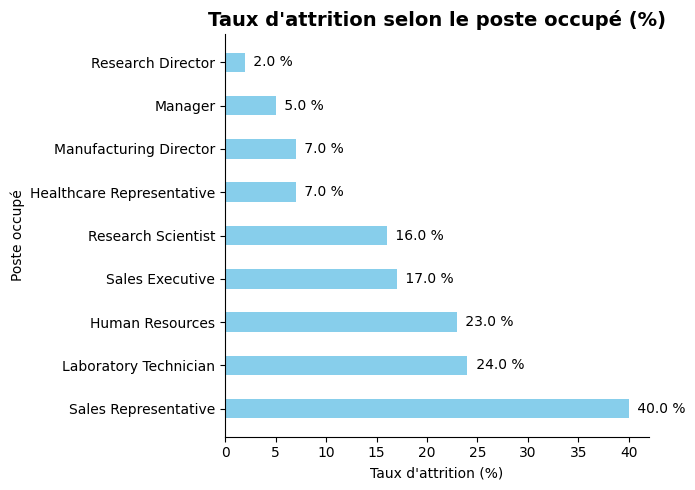

(None,)

In [38]:
fig , ax = plt.subplots(figsize=(7,5))

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Données
x = np.arange(len(pivot_jobrole_attrition.index))
y = pivot_jobrole_attrition["Yes"]

# Barplot

barhs = ax.barh(x, y, height=0.45, color="skyblue")

# Pourcentage affiché
ax.bar_label(barhs, labels=[f"{v : .1F} %" for v in y], padding=3)

# Axes et labels
ax.set_yticks(x)
ax.set_yticklabels(pivot_jobrole_attrition.index)

ax.set_xlabel("Taux d'attrition (%)")
ax.set_ylabel("Poste occupé")
ax.set_title("Taux d'attrition selon le poste occupé (%)", fontsize=14, fontweight="bold")

fig.tight_layout()
plt.show(),

On observe que le taux d'attrition est le plus elevé pour les employés occupant un poste de **Sales Representative** (40%). La fonction des **Laboratoy Technician** et des **Human Ressources** presentent un taux d'attrition élevé (entre 23 et 24 %).
A l'inverse les postes de **Research Director** (2 %) et **Manager** (5 %)ont un taux d'attrition faible.

#### 2.2.1.2 Attrition et les heures supplémentaires
---

##### Tableau de proportions ­­

In [39]:
overtime_attrition = df_conditions_travail[["OverTime","Attrition"]]
overtime_attrition

# Table pivot ligne = Overtime, colonne = Attrition, valeur = Pourcentage
pivot_overtime_attrition = pivot_percent(overtime_attrition, "OverTime","Attrition")
pivot_overtime_attrition = pivot_overtime_attrition.sort_values("Yes",ascending=False)
pivot_overtime_attrition

Attrition,No,Yes
OverTime,,
Yes,69.0,31.0
No,90.0,10.0


##### Graphique — Analyse de la relation entre les heures supplémentaires et l'attrition

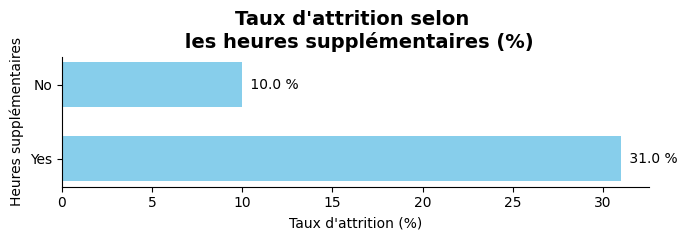

(None,)

In [53]:

fig, ax = plt.subplots(figsize=(7,2.5))


ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Données
x= np.arange(len(pivot_overtime_attrition.index))
y = pivot_overtime_attrition["Yes"]

# Barplot
barhs = ax.barh(x, y, height=0.6, color="skyblue")

# Pourcentage affiché
ax.bar_label(barhs, labels=[f"{v : .1F} %" for v in y], padding=3)

# Axe et label
ax.set_yticks(x)
ax.set_yticklabels(pivot_overtime_attrition.index)

ax.set_xlabel("Taux d'attrition (%)")
ax.set_ylabel("Heures supplémentaires")
ax.set_title("Taux d'attrition selon \n les heures supplémentaires (%)", fontsize=14, fontweight="bold")

fig.tight_layout()
plt.show(),

On observe que le taux d'attrition est plus elevé pour les employés ayant déclaré effectué des heures supplémenentaires (31 %).

#### 2.2.2 Attrition et la rémuneration
---

Dans cette partie, les variables analysé avec l'attrition sont le revenu mensuel et le pourcentage d'augmentation de salaires


#### 2.2.2.1 Attrition et Revenu Mensuel
---

##### Tableau de proportions ­­

In [41]:
monthlyIncome_attrition = df_conditions_travail[["Tranche_Salaire","Attrition" ]]
monthlyIncome_attrition

# Table pivot ligne = Tranche salaire, colonne = Attrition, valeur = pourcentage
pivot_monthlyIncome_attrition = pivot_percent(monthlyIncome_attrition,"Tranche_Salaire","Attrition")
pivot_monthlyIncome_attrition.sort_values("Yes",ascending=False)

Attrition,No,Yes
Tranche_Salaire,,
< 2 500,66.0,34.0
2 500 - 5 000,84.0,16.0
> 7 500,89.0,11.0
5 000 - 7 500,90.0,10.0


##### Graphique — Analyse de la relation entre le revenu mensuel et l'attrition

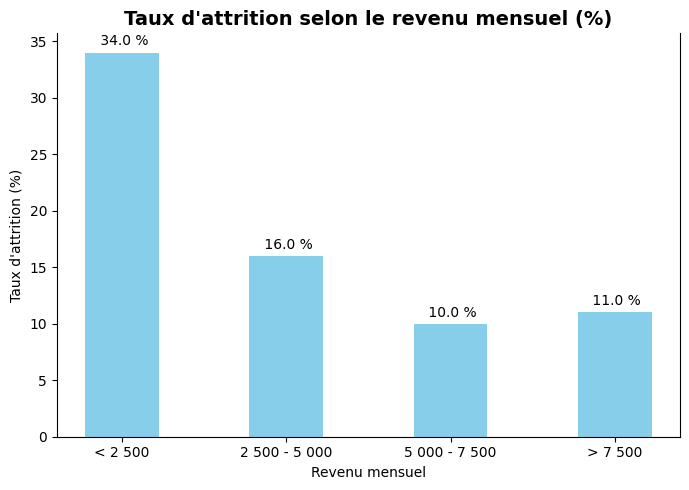

(None,)

In [42]:
pivot_monthlyIncome_attrition = pivot_monthlyIncome_attrition.sort_values("Tranche_Salaire", ascending=True)

fig, ax = plt.subplots(figsize=(7,5))

ax.spines["top"].set_visible(False)
ax.spines["top"].set_visible(False)

# Données
x= np.arange(len(pivot_monthlyIncome_attrition.index))
y = pivot_monthlyIncome_attrition["Yes"]

# Barplot
bars = ax.bar(x, y, width=0.45, color="skyblue")

# Affiché pourcentage
ax.bar_label(bars, labels=[f'{v : .1F} %' for v in y], padding=3)

# Axes et labels
ax.set_xticks(x)
ax.set_xticklabels(pivot_monthlyIncome_attrition.index)

ax.set_xlabel("Revenu mensuel")
ax.set_ylabel("Taux d'attrition (%)")
ax.set_title("Taux d'attrition selon le revenu mensuel (%)", fontsize=14, fontweight="bold")
fig.tight_layout()
plt.show(),

Ce graphique met en évidence que les employés ayant un revenu mensuel **inférieur à 2 500** présentent le taux d’attrition le plus élevé (**≈34 %**).

À l’inverse, le taux d’attrition est le plus faible pour la tranche de revenu **5 000 – 7 500** (≈10 %).

On observe ainsi **une diminution globale du taux d’attrition à mesure que le revenu mensuel augmente**, même si cette tendance n’est pas strictement monotone sur l’ensemble des tranches.

#### 2.2.2.1 Attrition et Le pourcentage d'augmentation de salaire
---

##### Tableau de proportions ­­

In [48]:
PercentSalaryHike_attrition = df_conditions_travail[["Tranche_PercentSalaryHike", "Attrition"]]
PercentSalaryHike_attrition

# Pivot table ligne= PercentSalaryHike, colonnes = Attrition, valeurs= Pourcentage

pivot_PercentSalaryHike_attrition = pivot_percent(PercentSalaryHike_attrition, "Tranche_PercentSalaryHike", "Attrition")
pivot_PercentSalaryHike_attrition.sort_values("Yes",ascending=False)

Attrition,No,Yes
Tranche_PercentSalaryHike,,
< 12,82.0,18.0
15-18,84.0,16.0
12-15,85.0,15.0
> 18,85.0,15.0


##### Graphique — Analyse de la relation entre le pourcentage d'augmentation de salaire et l'attrition

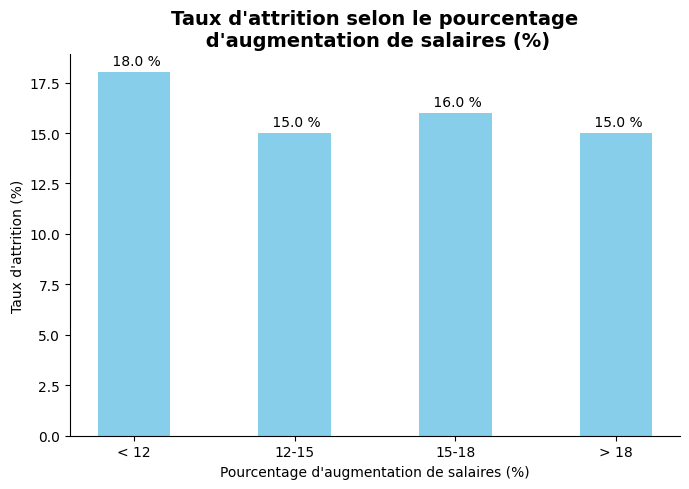

In [56]:

fig , ax = plt.subplots(figsize=(7,5))
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Données
x = np.arange(len(pivot_PercentSalaryHike_attrition.index))
y = pivot_PercentSalaryHike_attrition["Yes"]

# Barplot
bars = ax.bar(x, y, width=0.45, color="skyblue")

# Pourcentage affiché
ax.bar_label(bars, labels=[f"{v : .1F} %" for v in y], padding=3)

# Axes et labels
ax.set_xticks(x)
ax.set_xticklabels(pivot_PercentSalaryHike_attrition.index)

ax.set_xlabel("Pourcentage d'augmentation de salaires (%)")
ax.set_ylabel("Taux d'attrition (%)")
ax.set_title("Taux d'attrition selon le pourcentage\n d'augmentation de salaires (%)", fontsize=14, fontweight="bold")

fig.tight_layout()
plt.show()

Ce graphique met en évidence un taux d’attrition légèrement plus élevé pour les employés ayant bénéficié d’une augmentation de salaire **inférieure à 12 %.**

Toutefois, la distribution du taux d’attrition **reste relativement homogène entre les différentes tranches**, avec des valeurs comprises entre **15 % et 18 %**, suggérant une relation peu différenciante entre le pourcentage d’augmentation de salaire et l’attrition dans ce jeu de données.

#### 2.2.3 Attrition et Ancienneté/carrière
---

Dans cette partie, les variables analysé avec l'attrition sont l'ancienneté dans l'entreprise et l'ancienneté dans le poste actuel

#### 2.2.3.1 Attrition et Ancienneté
---

##### Tableau de proportions

In [61]:
yearsAtCompany_attrition = df_conditions_travail[["Tranche_Anciennete", "Attrition"]]
yearsAtCompany_attrition

# pivot table , ligne = ancienneté, colonnes = Attrition, valeur = pourcentage

pivot_yearsAtCompany_attrition = pivot_percent(yearsAtCompany_attrition, "Tranche_Anciennete", "Attrition")
pivot_yearsAtCompany_attrition.sort_values("Yes", ascending=False)

Attrition,No,Yes
Tranche_Anciennete,,
≤ 2 ans,70.0,30.0
3-5 ans,86.0,14.0
6-10 ans,88.0,12.0
> 20 ans,88.0,12.0
16-20 ans,93.0,7.0
11-15 ans,94.0,6.0


##### Graphique — Analyse de la relation entre l'ancienneté et l'attrition

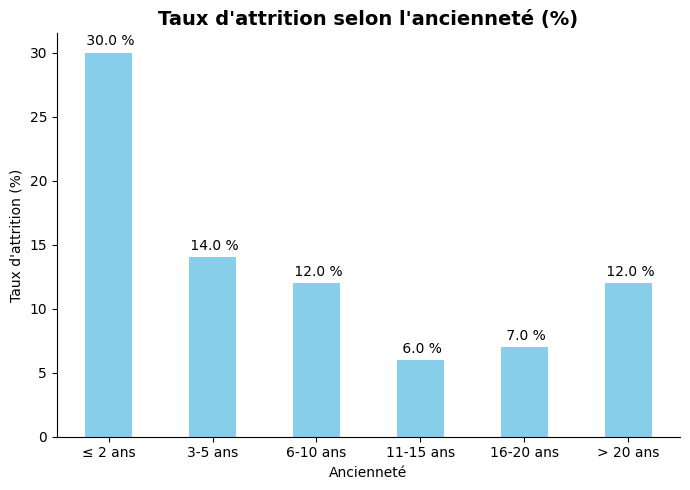

(None,)

In [65]:
fig, ax = plt.subplots(figsize=(7,5))

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Données
x = np.arange(len(pivot_yearsAtCompany_attrition.index))
y =  pivot_yearsAtCompany_attrition["Yes"]

# barplot
bars = ax.bar(x, y, width=0.45, color="skyblue")

# Pourcentage affiché
ax.bar_label(bars, labels=[f"{v : .1F} %" for v in y ], padding=3)

# Axes et labels
ax.set_xticks(x)
ax.set_xticklabels(pivot_yearsAtCompany_attrition.index)

ax.set_xlabel("Ancienneté")
ax.set_ylabel("Taux d'attrition (%)")
ax.set_title("Taux d'attrition selon l'ancienneté (%)", fontsize=14, fontweight="bold")

fig.tight_layout()
plt.show(),

On observe que le taux d’attrition est le plus élevé chez **les nouveaux salariés**, avec environ **30 %** de départs.

Le taux d’attrition diminue nettement pour les employés ayant entre **3 et 10 ans d’ancienneté**, avec des valeurs comprises entre **12 % et 14 %**, puis atteint des niveaux très faibles pour les salariés ayant une ancienneté **longue ou très longue** (environ **6 à 7 %**).

Une légère remontée du taux d’attrition est observée pour les employés ayant une ancienneté supérieure à 20 ans (≈12 %), toutefois cette tranche regroupe un effectif limité, ce qui invite à une interprétation prudente.

#### 2.2.3.2 Attrition et Ancienneté dans le poste
---

##### Tableau de proportions

In [64]:
yearsInCurrentRole_attrition = df_conditions_travail[["Tranche_PosteAnciennete", "Attrition"]]
yearsInCurrentRole_attrition

# pivot table , ligne = ancienneté dans le poste , colonnes = Attrition, valeur = pourcentage

pivot_yearsInCurrentRole_attrition = pivot_percent(yearsInCurrentRole_attrition, "Tranche_PosteAnciennete", "Attrition")
pivot_yearsInCurrentRole_attrition

Attrition,No,Yes
Tranche_PosteAnciennete,,
≤ 2 ans,77.0,23.0
3-5 ans,88.0,12.0
6-10 ans,89.0,11.0
> 10 ans,94.0,6.0


##### Graphique — Analyse de la relation entre l'lancienneté dans le poste et l'attriton

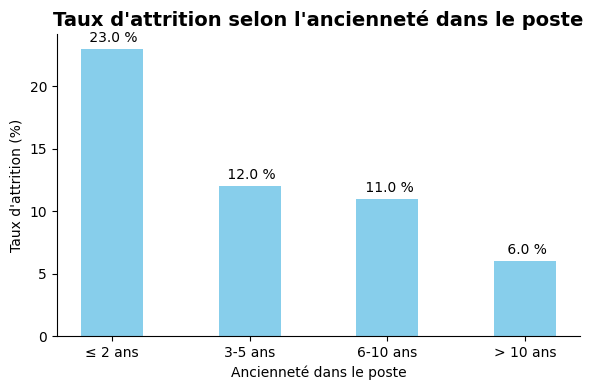

(None,)

In [74]:
fig , ax = plt.subplots(figsize=(6,4))

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Données
x = np.arange(len(pivot_yearsInCurrentRole_attrition.index))
y =  pivot_yearsInCurrentRole_attrition["Yes"]

# barplot
bars = ax.bar(x, y, width=0.45, color="skyblue")

# Pourcentage affiché
ax.bar_label(bars, labels=[f"{v : .1F} %" for v in y], padding=3)

# Axes et labels 
ax.set_xticks(x)
ax.set_xticklabels(pivot_yearsInCurrentRole_attrition.index)
ax.set_xlabel("Ancienneté dans le poste")
ax.set_ylabel("Taux d'attrition (%)")
ax.set_title("Taux d'attrition selon l'ancienneté dans le poste", fontsize=14, fontweight="bold")

fig.tight_layout()
plt.show(),

Ce graphique mets en evidence que le taux d'attrition le plus elevé est representé par les employés dont l'ancienneté dans le poste est inférieur à 2 ans. A l'inverse les salariés ayant une ancienneté dans leur poste de plus de 10 ans ont le taux d'attrition le plus faibe (6 %)

On observe une dimunition globale du taux d'attrition a mesure que l'ancienneté dans le poste augmente.

Ce graphique met en évidence que le taux d’attrition est le plus élevé chez les employés dont l’ancienneté dans **le poste est inférieure à 2 ans** (≈23 %).
À l’inverse, les salariés occupant le même poste depuis **plus de 10 ans** présentent le taux d’attrition le plus faible (**≈6 %**).
On observe ainsi u**ne diminution globale du taux d’attrition à mesure que l’ancienneté dans le poste augmente**.

##### 2.2.3.3 Attrition et expérience professionnelle totale

##### Tableau de proportions

In [81]:
TotalWorkingYears_attrition = df_conditions_travail[["Tranche_ExperiencePro", "Attrition"]]
TotalWorkingYears_attrition

pivot_TotalWorkingYears_attrition = pivot_percent(TotalWorkingYears_attrition, "Tranche_ExperiencePro", "Attrition")
pivot_TotalWorkingYears_attrition

Attrition,No,Yes
Tranche_ExperiencePro,,
≤ 2 ans,56.0,44.0
3-5 ans,81.0,19.0
6-10 ans,85.0,15.0
11-15 ans,87.0,13.0
> 15 ans,91.0,9.0


##### Graphique — Analyse de la relation entre l'experience professionnelle  et l'attriton

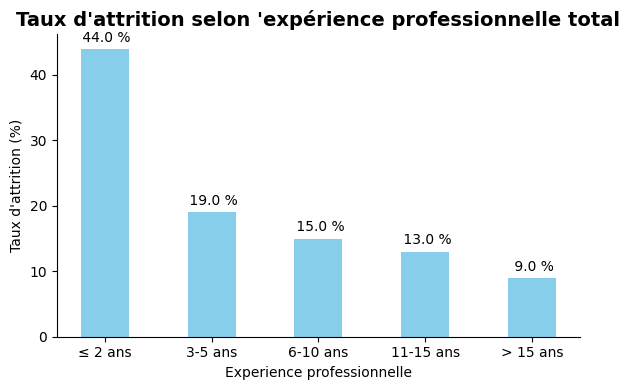

(None,)

In [82]:
fig , ax = plt.subplots(figsize=(6,4))

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Données
x = np.arange(len(pivot_TotalWorkingYears_attrition.index))
y =  pivot_TotalWorkingYears_attrition["Yes"]

# barplot
bars = ax.bar(x, y, width=0.45, color="skyblue")

# Pourcentage affiché
ax.bar_label(bars, labels=[f"{v : .1F} %" for v in y], padding=3)

# Axes et labels 
ax.set_xticks(x)
ax.set_xticklabels(pivot_TotalWorkingYears_attrition.index)
ax.set_xlabel("Experience professionnelle")
ax.set_ylabel("Taux d'attrition (%)")
ax.set_title("Taux d'attrition selon 'expérience professionnelle total", fontsize=14, fontweight="bold")

fig.tight_layout()
plt.show(),

Le taux d’attrition varie fortement selon le niveau d’expérience professionnelle totale.

Les employés ayant **≤ 2 ans d’expérience** présentent un taux d’attrition très élevé (**44 %**).
À l’inverse, le taux d’attrition diminue progressivement avec l’augmentation de l’expérience professionnelle, pour atteindre **9 %** chez les employés ayant **plus de 15 ans d’expérience**.

Cette évolution suggère une relation inverse marquée entre l’expérience professionnelle globale et l’attrition.

#### 2.2.4 Attrition et l'évolution/Management
---

##### 2.2.4.1 Attrition et le délai écoulé depuis la derniere promotion
---

##### Tableau de proportions

In [76]:
YearsSinceLastPromotion_attrition = df_conditions_travail[["Tranche_LastPromotion", "Attrition"]]
YearsSinceLastPromotion_attrition
# pivot table , ligne = ancienneté, colonnes = Attrition, valeur = pourcentage

pivot_YearsSinceLastPromotion_attrition = pivot_percent(YearsSinceLastPromotion_attrition, "Tranche_LastPromotion", "Attrition")
pivot_YearsSinceLastPromotion_attrition.sort_values("Yes", ascending=False)

Attrition,No,Yes
Tranche_LastPromotion,,
6-10 ans,82.0,18.0
< 1 an,83.0,17.0
1-2 ans,83.0,17.0
> 10 ans,88.0,12.0
3-5 ans,90.0,10.0


##### Graphique — Analyse de la relation entre le délai écoulé depuis la derniere promotion et l'attrition

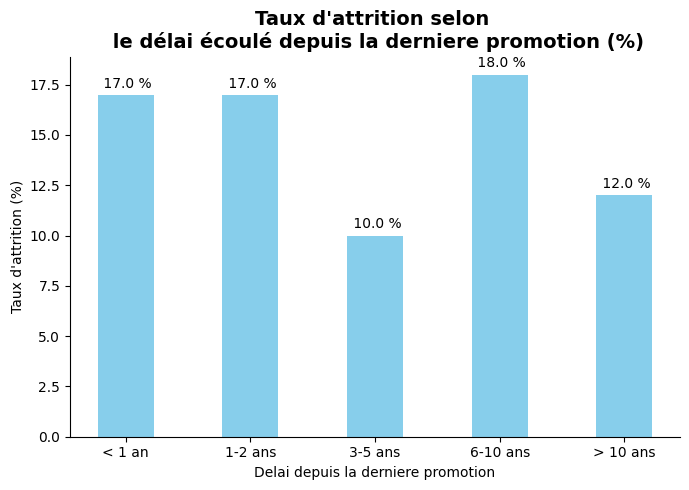

(None,)

In [79]:
fig , ax = plt.subplots(figsize=(7,5))

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Données
x = np.arange(len(pivot_YearsSinceLastPromotion_attrition.index))
y =  pivot_YearsSinceLastPromotion_attrition["Yes"]

# Barplot
bars = ax.bar(x, y, width=0.45, color="skyblue")

# Pourcentage affiché
ax.bar_label(bars, labels=[f"{v : .1F} %" for v in y], padding=3)

# Axes et labels
ax.set_xticks(x)
ax.set_xticklabels(pivot_YearsSinceLastPromotion_attrition.index)

ax.set_xlabel("Delai depuis la derniere promotion")
ax.set_ylabel("Taux d'attrition (%)")
ax.set_title("Taux d'attrition selon \n le délai écoulé depuis la derniere promotion (%)", fontsize=14, fontweight="bold")

fig.tight_layout()
plt.show(),

Ce graphique met en évidence **des différences modérées** de taux d’attrition selon le délai écoulé depuis la dernière promotion.

Le taux d’attrition est légèrement plus élevé pour les employés dont la dernière promotion remonte **à 6–10 ans** (≈18 %), ainsi que pour ceux ayant été promus **récemment** (moins d’1 an ou 1–2 ans, ≈17 %).
À l’inverse, la tranche **3–5 ans** présente le taux d’attrition le plus faible (**≈10 %)**.

Toutefois, l’absence de tendance clairement croissante ou décroissante suggère **une relation peu structurée** entre le délai depuis la dernière promotion et l’attrition.

#### 2.3 Résultats clés - Conditions de travail et attrition
---

L’attrition est particulièrement élevée chez les salariés en début d’ancienneté.

Les postes commerciaux et les situations d’heures supplémentaires présentent des taux d’attrition plus élevés.

Le taux d’attrition diminue globalement avec l’augmentation du revenu mensuel.

Certaines variables organisationnelles (ex. délai depuis la dernière promotion) présentent des variations limitées et peu structurées.

Une fois les comparaisons simples réalisées, j’explore les relations internes à l’axe afin d’identifier d’éventuels patterns ou corrélations.

## 3. Relations internes à l’axe condition de travail
----

### 3.1 Introduction

Après avoir analysé les relations entre les variables personnelles et l’attrition, cette section vise à explorer les relations internes entre les variables de l’axe *Condition de travail*, afin d’identifier d’éventuels patterns ou profils récurrents.  
Les variables sont analysées à partir de tableaux croisés et de visualisations graphiques descriptives.

---


### 3.2 Analyse des relations entre variables organisationnelles

#### 3.2.1 Relation entre 
---

##### Tableaux croisés

##### Visualisation

##### Observations descriptives



#### 3.2.2 Relation entre 
---


##### Tableaux croisés

##### Visualisation

##### Observations descriptives


#### 3.2.3 Relation entre 
---


##### Tableau croisé

##### Visualisation

##### Observations descriptives



Après avoir analysé ces trois relations, cette section synthétise les principaux patterns observés.

### 3.3 Synthèse des patterns observés
---
Les analyses des relations internes à l’axe *Condition de travail* mettent en évidence plusieurs patterns structurants :

- **Pattern 1 — Relation entre**  
  
- **Pattern 2 — Relation entre**  
  
- **Pattern 3 — Relation entre**  
  
  Ces patterns permettent de mieux contextualiser les résultats observés précédemment et servent de base à la synthèse globale de l’axe Condition de travail.
  ---

# 4. Résultats clés 
---


---

# 5. Conclusion de l’axe “Condition de travail”
---

